In [84]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import platform

if platform.system() == 'Windows':
    matplotlib.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    matplotlib.rc('font', family='AppleGothic')
else:
    matplotlib.rc('font', family='DejaVu Sans')

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

print('NumPy 버전:', np.__version__)
print('환경 설정 완료')

NumPy 버전: 2.3.5
환경 설정 완료


In [12]:
df.shape

(3650, 7)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   날짜      310 non-null    object
 1   순위      310 non-null    object
 2   영화명     310 non-null    object
 3   개봉일     310 non-null    object
 4   일일관객수   310 non-null    object
 5   누적관객수   310 non-null    object
 6   일일매출액   310 non-null    object
dtypes: object(7)
memory usage: 17.1+ KB


In [15]:
# df 객체를 파일로 저장
df.to_csv('data/kobis.csv', encoding='utf-8', index=False)

- 월별 박스오피스 1등 리스트업

In [ ]:


# '날짜' 컬럼의 데이터타입 변경 - datetime
df['날짜'] = pd.to_datetime(df['날짜'])
df.dtypes

# 년, 월, 일, 요일 컬럼 생성
df['연도'] = df['날짜'].dt.year
df['월'] = df['날짜'].dt.month
df['일'] = df['날짜'].dt.day
df['요일'] = df['날짜'].dt.weekday
df

In [19]:
# 요일 변경
week_dict = {
    0: '월',
    1: '화',
    2: '수',
    3: '목',
    4: '금',
    5: '토',
    6: '일',
}
df['요일'] = df['날짜'].dt.weekday.map(week_dict)
df['요일'].value_counts()

요일
수    530
목    520
금    520
토    520
일    520
월    520
화    520
Name: count, dtype: int64

In [ ]:
df.info()

In [40]:
df['순위'].value_counts()
df_rank1 = df[df['순위'] == '1']
df_rank1

# 2025년 기준 Top of Top 10
df['일일관객수'] = df['일일관객수'].astype(int)
df['일일관객수'].dtypes
df_rank1_top10 = df.groupby('영화명')['일일관객수'].sum().sort_values(ascending=False).head(10)
df_rank1_top10

영화명
주토피아 2              7703922
극장판 귀멸의 칼날: 무한성편    5650903
좀비딸                 5605086
F1 더 무비             5176850
아바타: 불과 재           4568158
극장판 체인소 맨: 레제편      3406687
미션 임파서블: 파이널 레코닝    3380126
야당                  3370527
미키 17               2996149
어쩔수가없다              2925337
Name: 일일관객수, dtype: int64

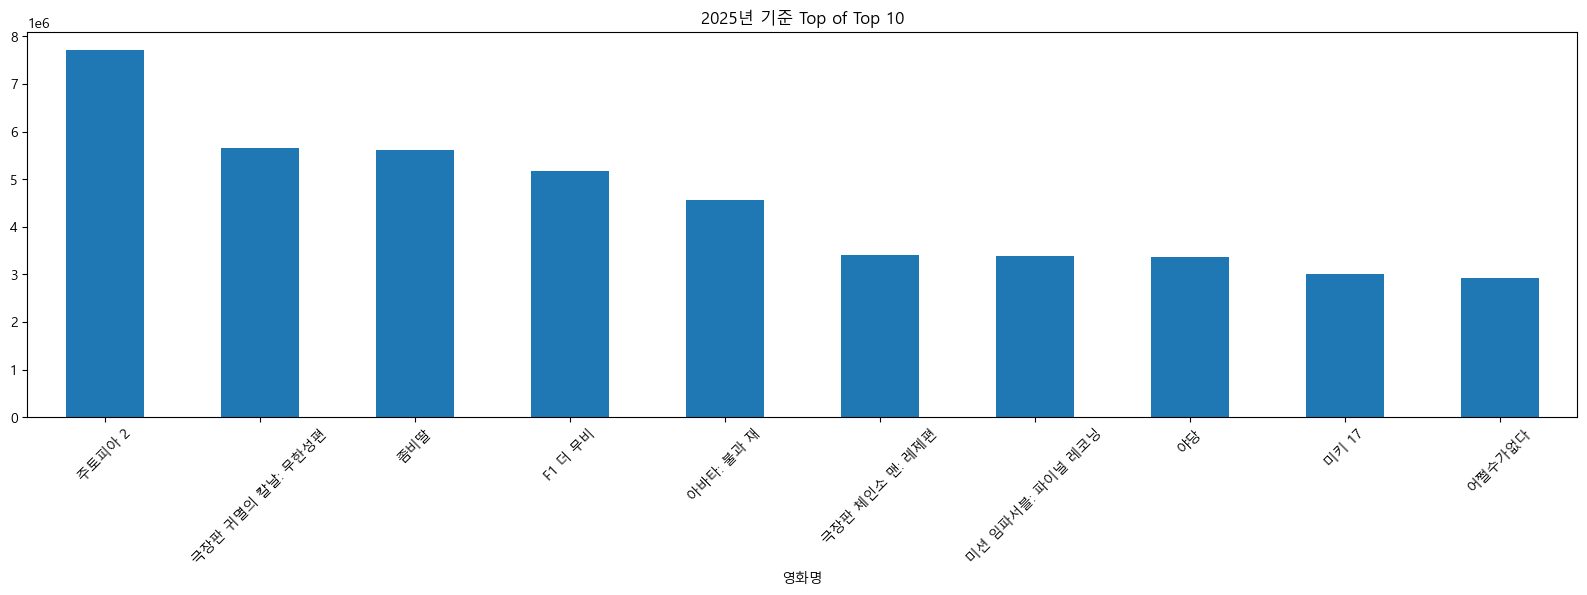

In [50]:
df_rank1_top10.plot(
    kind='bar',
    figsize=(20, 5)
)
plt.title('2025년 기준 Top of Top 10')
plt.xticks(rotation=45)
# plt.grid()
plt.show()

- 월별 총 매출액 기준 Top10
- 그래프 생성 시 월별로 정렬(1~12)

In [73]:
df['일일매출액'] = df['일일매출액'].astype(int)
df_month_top10 = df.groupby('월')['일일매출액'].sum()
df_month_top10

월
1      76426460660
2      47082683466
3      55772809470
4      46966204130
5      77570405180
6      69262625020
7     108647423776
8     126989955840
9      70064275110
10     89208664310
11     65397825630
12    134856286132
Name: 일일매출액, dtype: int64

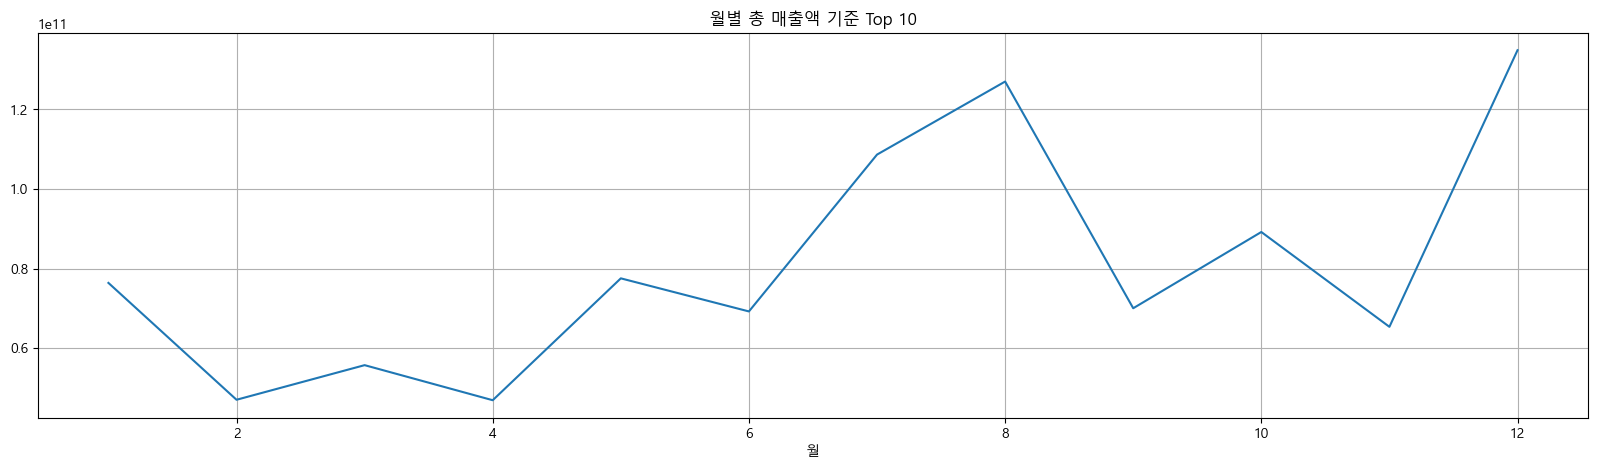

In [87]:
df_month_top10.plot(
    kind='line',
    figsize=(20, 5)
)
plt.title('월별 총 매출액 기준 Top 10')
# plt.xticks(rotation=45)
plt.grid()
plt.show()

- 요일별 관객수 추이

In [89]:
weekday = ['월','화','수','목','금','토','일']
df_weekday = df.groupby('요일')['일일관객수'].sum().reindex(weekday)
df_weekday

요일
월     8318811
화     7951556
수    12657300
목    10303793
금    13034054
토    24433622
일    21394197
Name: 일일관객수, dtype: int64

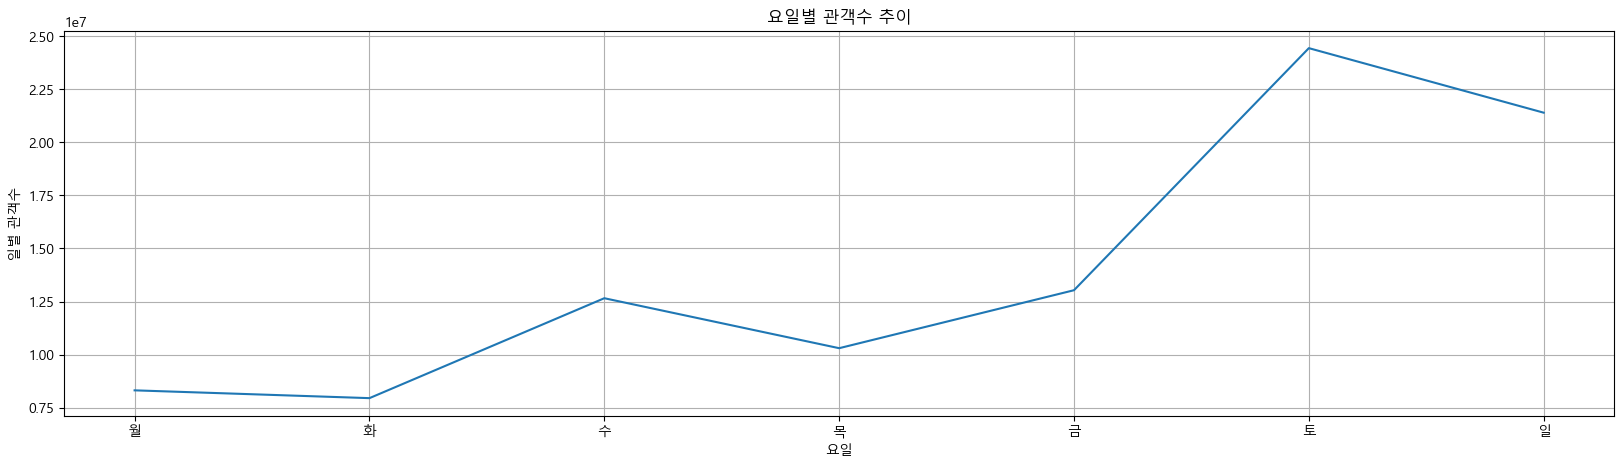

In [95]:
df_weekday.plot(
    kind='line',
    figsize=(20, 5)
)
plt.title('요일별 관객수 추이')
plt.ylabel('일별 관객수')
plt.grid()
plt.show()